In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys
sys.path.append("../src")

from rwe_health_analytics.data.data_loader import HealthcareDataLoader


In [6]:
loader = HealthcareDataLoader("../data/raw")
data = loader.load_all()

patients = data["demographics"]
diagnoses = data["diagnoses"]
labs = data["lab_results"]
meds = data["medications"]
outcomes = data["outcomes"]



INFO:rwe_health_analytics.data.data_loader:Loading all datasets...
INFO:rwe_health_analytics.data.data_loader:Loading demographics from ..\data\raw\demographics.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 10000 patient records
INFO:rwe_health_analytics.data.data_loader:Loading diagnoses from ..\data\raw\diagnoses.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 30035 diagnosis records
INFO:rwe_health_analytics.data.data_loader:Loading lab results from ..\data\raw\lab_results.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 199701 lab results
INFO:rwe_health_analytics.data.data_loader:Loading medications from ..\data\raw\medications.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 21079 medication records
INFO:rwe_health_analytics.data.data_loader:Loading outcomes from ..\data\raw\outcomes.csv
INFO:rwe_health_analytics.data.data_loader:Loaded 23444 outcome events
INFO:rwe_health_analytics.data.data_loader:All datasets loaded successfully!


In [7]:
datasets = {
    "patients": patients,
    "diagnoses": diagnoses,
    "labs": labs,
    "medications": meds,
    "outcomes": outcomes
}

for name, df in datasets.items():
    print("="*70)
    print(f" {name.upper()} — shape: {df.shape}")
    display(df.head())


📌 PATIENTS — shape: (10000, 10)


,patient_id,age,gender,race,bmi,smoking_status,enrollment_date,charlson_score,zip_code,insurance_type
0,P000000,62,M,White,31.6,Former,2018-11-24,1,44166,Commercial
1,P000001,52,M,White,20.6,Never,2018-02-27,2,55903,Commercial
2,P000002,64,M,Other,28.7,Never,2018-01-13,3,22376,Uninsured
3,P000003,77,M,Asian,22.4,Never,2018-05-21,2,15666,Medicare
4,P000004,51,F,White,19.7,Never,2018-05-06,6,88172,Medicaid


📌 DIAGNOSES — shape: (30035, 6)


,patient_id,diagnosis_date,icd10_code,diagnosis_desc,diagnosis_type,visit_type
0,P000001,2023-02-18,M05,Rheumatoid arthritis,Secondary,Emergency
1,P000002,2019-12-21,G35,Multiple sclerosis,Primary,Outpatient
2,P000002,2018-07-04,I21,Acute myocardial infarction,Secondary,Outpatient
3,P000002,2022-02-06,E11,Type 2 diabetes mellitus,Secondary,Inpatient
4,P000003,2018-11-27,M05,Rheumatoid arthritis,Secondary,Emergency


📌 LABS — shape: (199701, 6)


,patient_id,test_date,test_name,test_value,unit,abnormal_flag
0,P000000,2021-12-09,Creatinine,0.79,mg/dL,N
1,P000000,2019-01-05,HDL,50.22,mg/dL,N
2,P000000,2019-06-03,LDL,105.06,mg/dL,N
3,P000000,2023-02-24,Creatinine,0.44,mg/dL,N
4,P000000,2022-03-03,Creatinine,0.26,mg/dL,N


📌 MEDICATIONS — shape: (21079, 7)


,patient_id,medication,start_date,end_date,dosage,frequency,prescriber_specialty
0,P000001,Metformin,2023-03-04,2023-05-11,20 mg,PRN,Oncology
1,P000002,Fingolimod,2019-12-28,2021-01-06,100 mg,TID,Neurology
2,P000002,Metformin,2022-02-12,2023-03-29,10 mg,PRN,Internal Medicine
3,P000003,Fingolimod,2018-12-05,2020-03-28,20 mg,TID,Oncology
4,P000003,Glipizide,2020-05-05,2021-07-22,100 mg,QD,Cardiology


📌 OUTCOMES — shape: (23444, 5)


,patient_id,event_type,event_date,los_days,censored
0,P000001,Hospitalization,2018-05-18,5.0,0
1,P000001,Hospitalization,2022-11-18,7.0,0
2,P000001,Hospitalization,2022-03-07,2.0,0
3,P000001,Hospitalization,2020-01-13,14.0,0
4,P000001,Hospitalization,2019-05-24,14.0,0


In [8]:
type(patients), type(diagnoses), type(labs), type(meds), type(outcomes)

(pandas.core.frame.DataFrame,
 pandas.core.frame.DataFrame,
 pandas.core.frame.DataFrame,
 pandas.core.frame.DataFrame,
 pandas.core.frame.DataFrame)

In [10]:
for name, df in datasets.items():
    print("="*70)
    print(f" {name.upper()} — info")
    print(df.info())
    print("\nMissing values per column:")
    print(df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())
    print("\n")


 PATIENTS — info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   patient_id       10000 non-null  object        
 1   age              10000 non-null  int64         
 2   gender           10000 non-null  object        
 3   race             10000 non-null  object        
 4   bmi              10000 non-null  float64       
 5   smoking_status   10000 non-null  object        
 6   enrollment_date  10000 non-null  datetime64[ns]
 7   charlson_score   10000 non-null  int64         
 8   zip_code         10000 non-null  int64         
 9   insurance_type   10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 781.4+ KB
None

Missing values per column:
patient_id         0
age                0
gender             0
race               0
bmi                0
smoking_status    

Data Quality Check — Outcomes

There are no missing values in the key columns (patient_id, event_type, event_date, censored).

The column los_days (lenght of stay) contains 2,464 missing values.
This is expected: these correspond to non-hospitalization events, where length of stay is not applicable.

A total of 1 duplicate row was detected (0.004% of the dataset).
It can be safely removed with no clinical impac

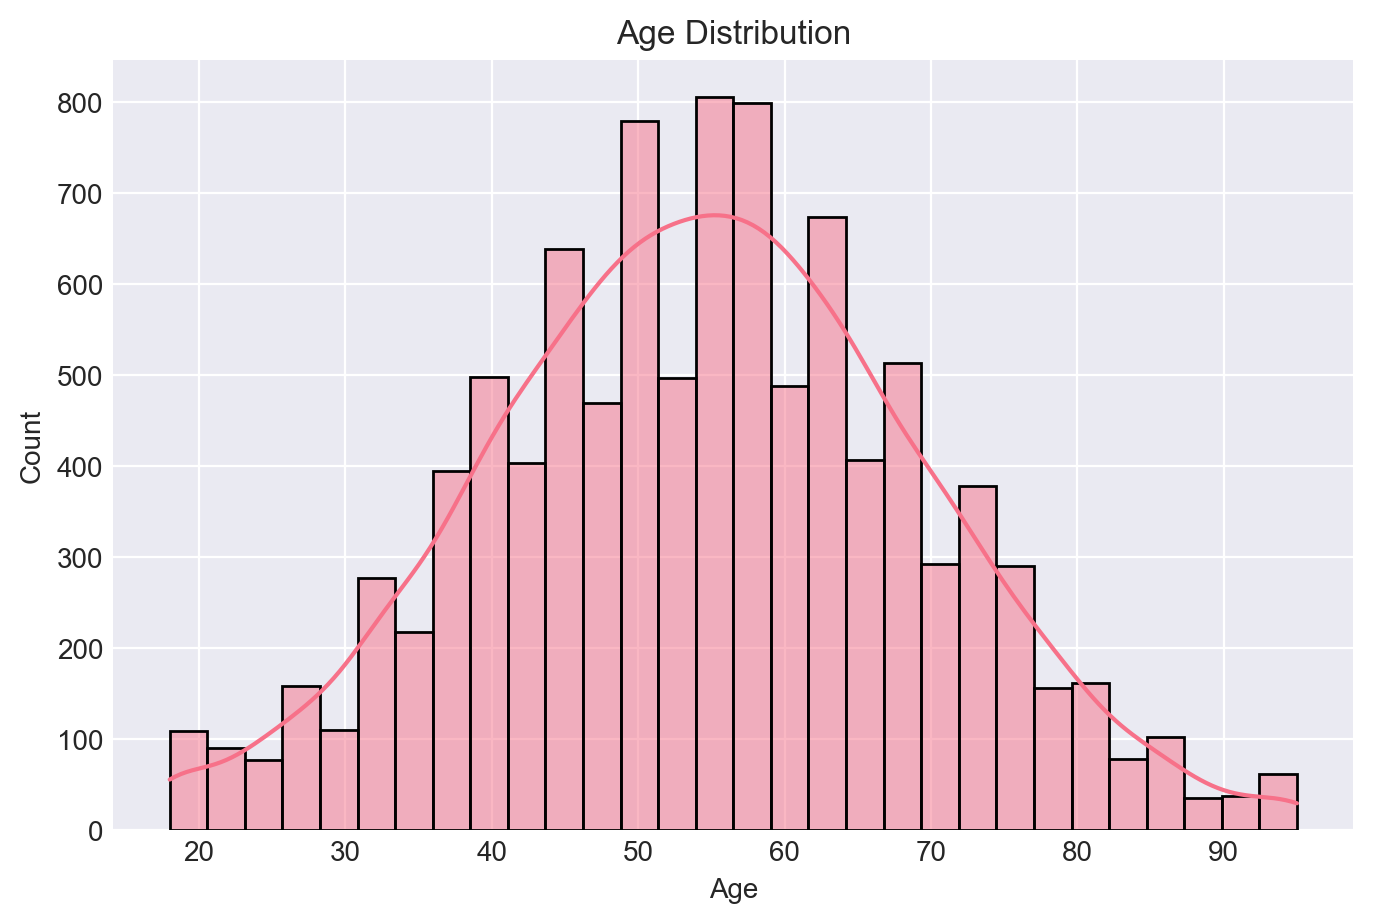

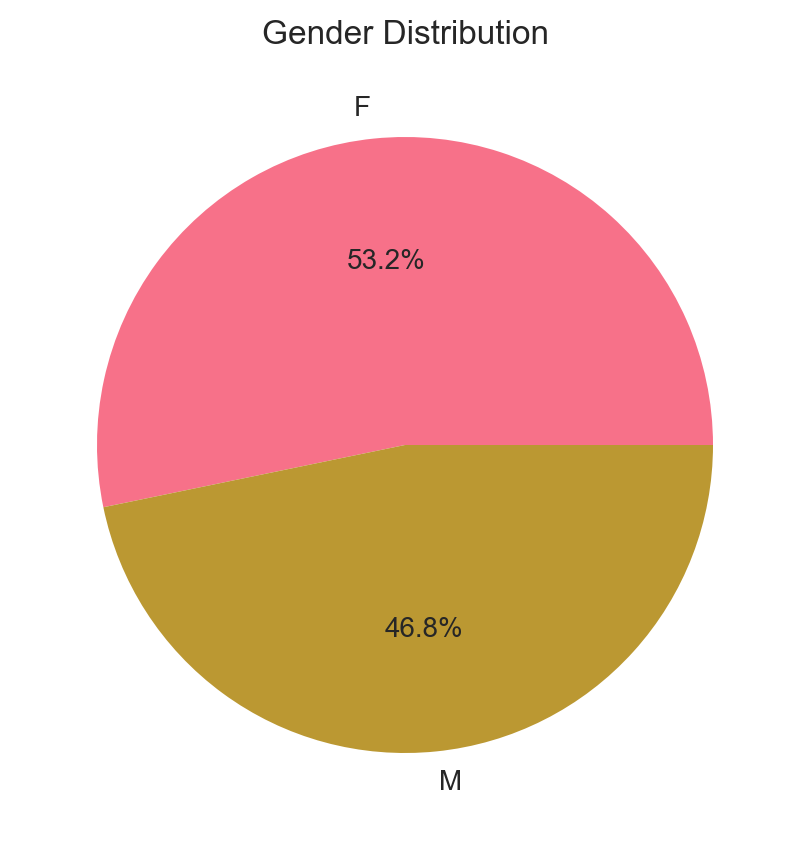

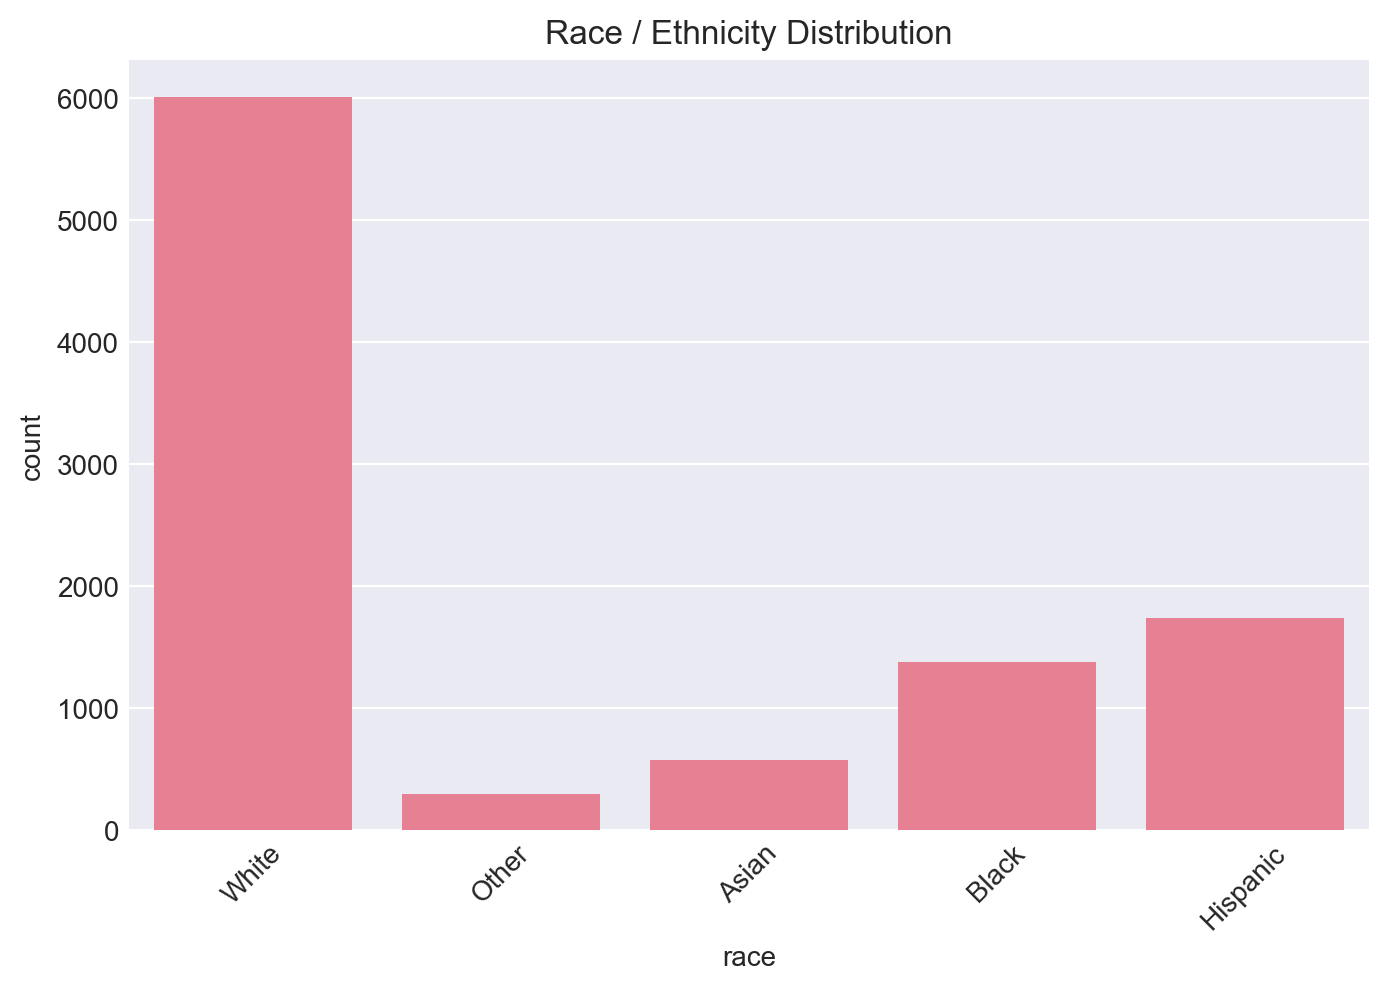

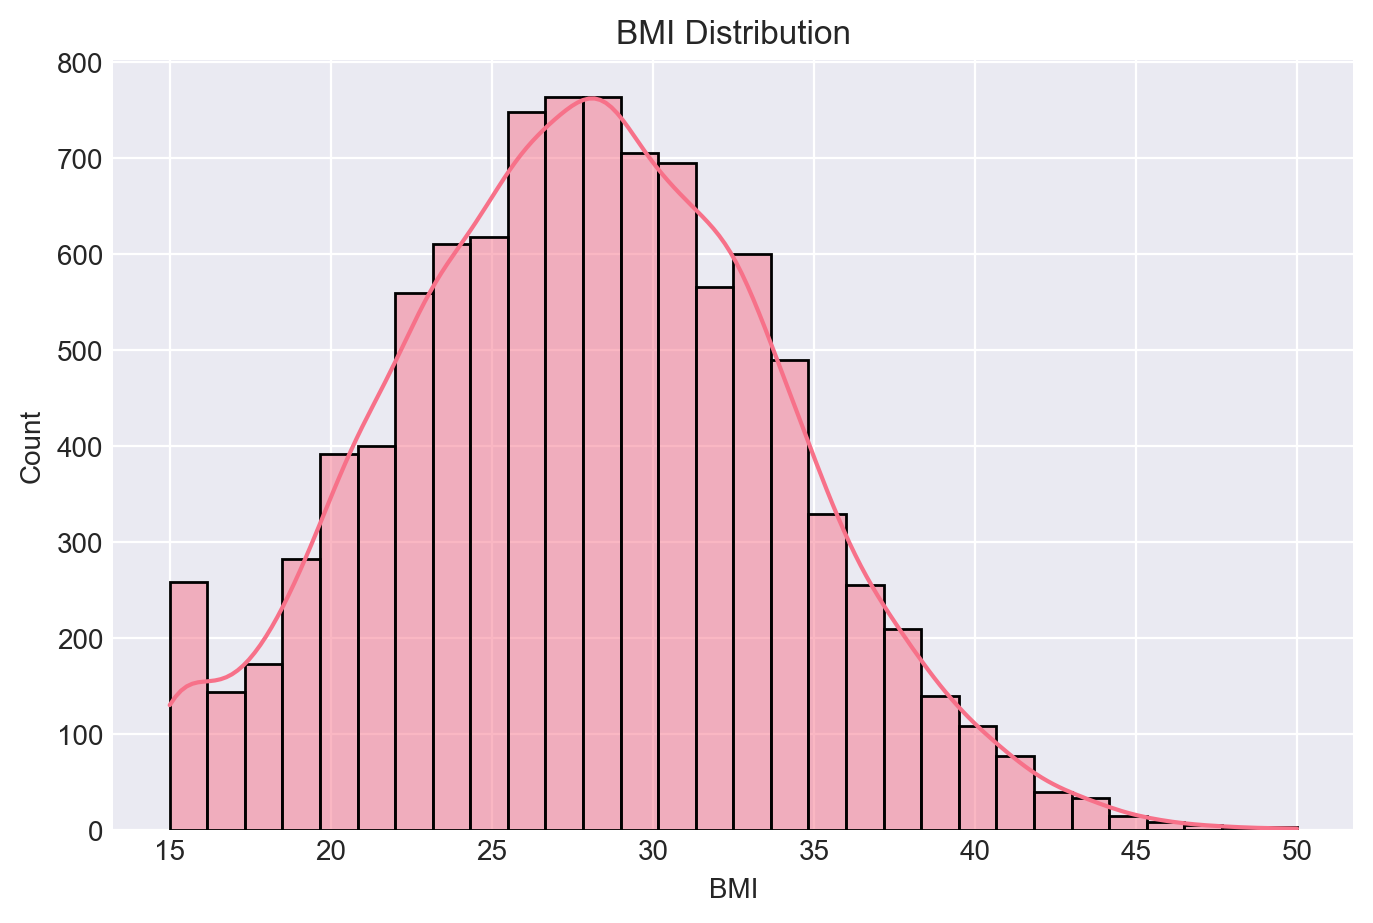

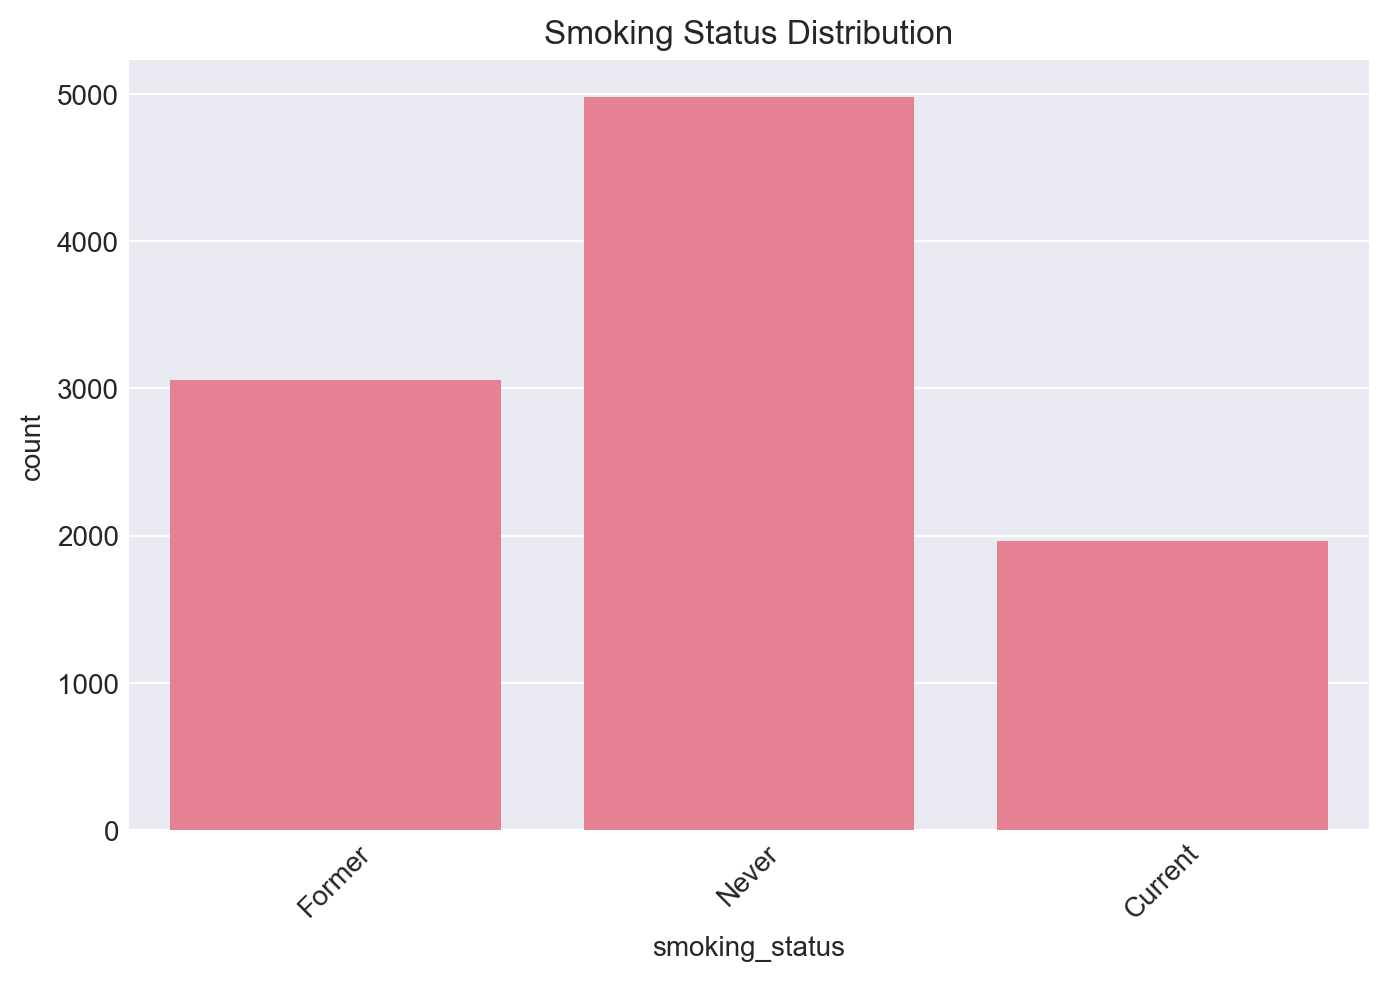

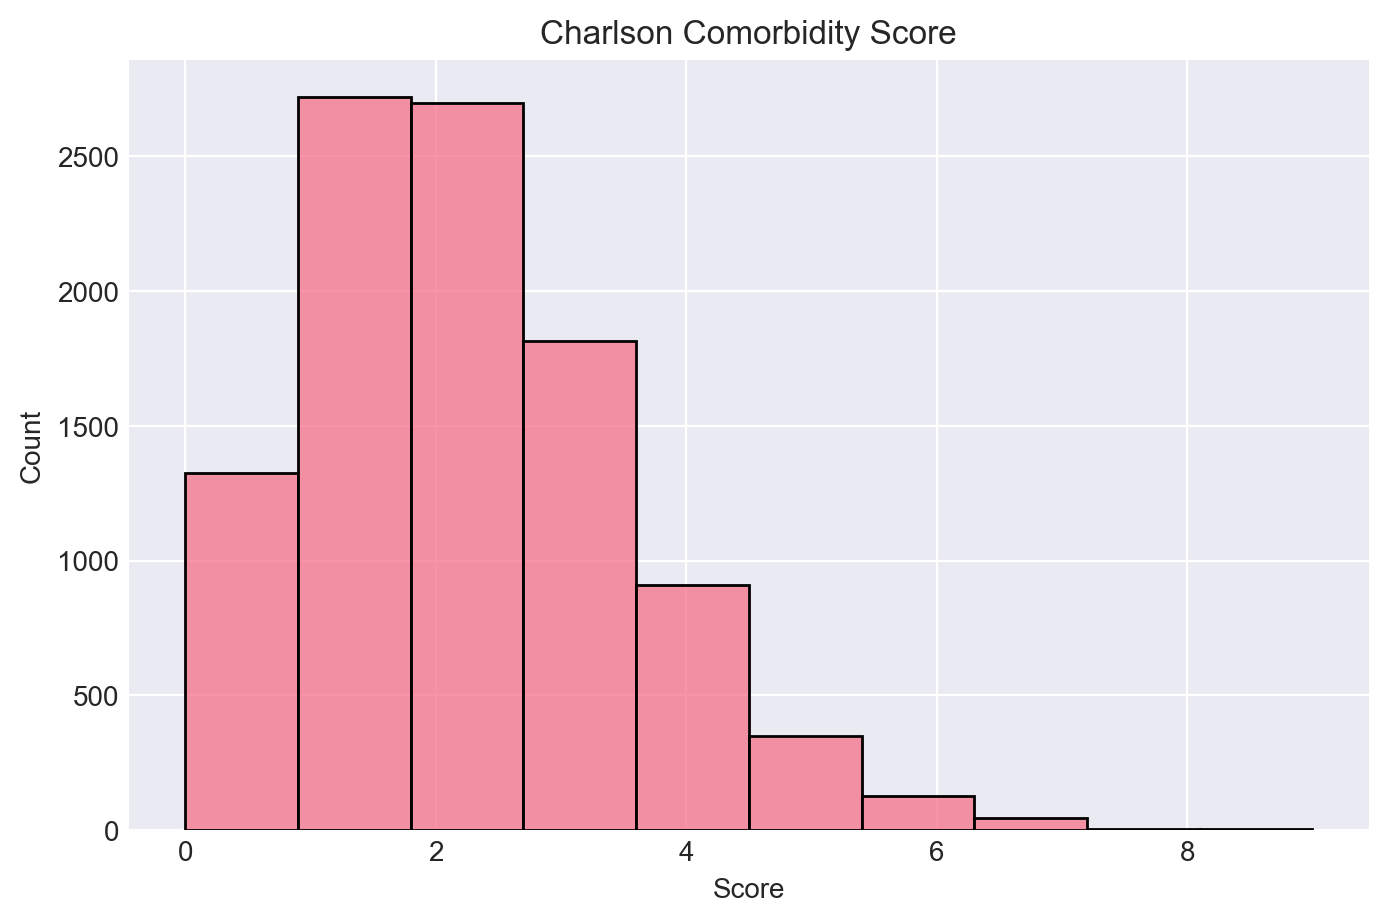

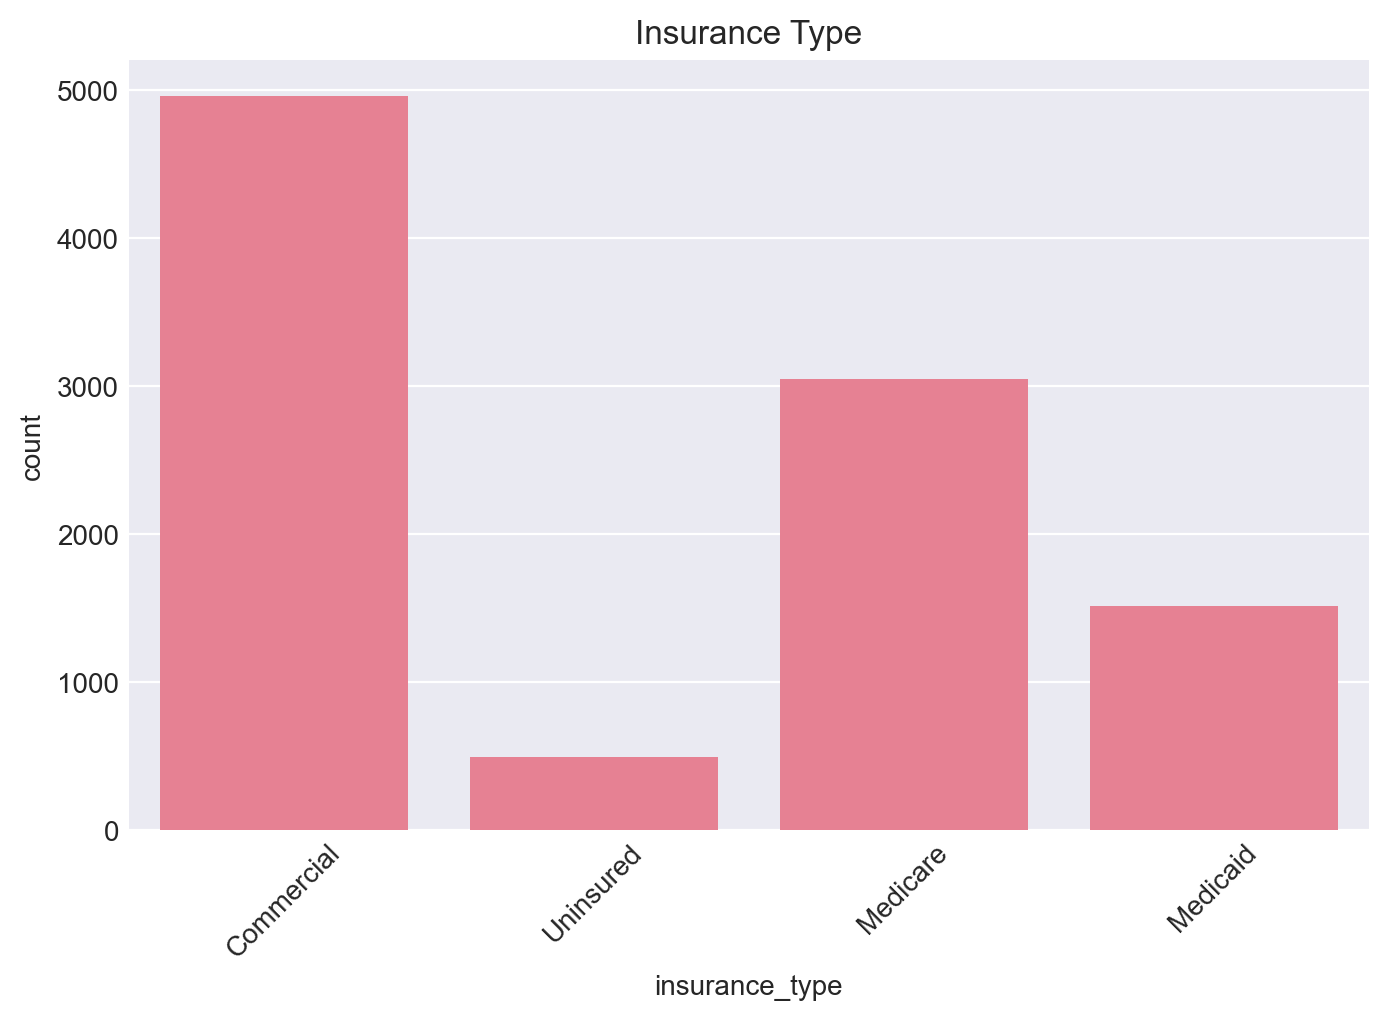

In [11]:
# ==============================================
#  
Basic exploration — Demographics
# ==============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

patients_df = patients.copy()

# --- AGE DISTRIBUTION ---
plt.figure(figsize=(8,5))
sns.histplot(patients_df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

# --- GENDER DISTRIBUTION ---
plt.figure(figsize=(5,5))
patients_df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# --- RACE ---
plt.figure(figsize=(8,5))
sns.countplot(data=patients_df, x="race")
plt.title("Race / Ethnicity Distribution")
plt.xticks(rotation=45)
plt.show()

# --- BMI ---
plt.figure(figsize=(8,5))
sns.histplot(patients_df["bmi"], bins=30, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.show()

# --- SMOKING STATUS ---
plt.figure(figsize=(8,5))
sns.countplot(data=patients_df, x="smoking_status")
plt.title("Smoking Status Distribution")
plt.xticks(rotation=45)
plt.show()

# --- CHARLSON COMORBIDITY ---
plt.figure(figsize=(8,5))
sns.histplot(patients_df["charlson_score"], bins=10, kde=False)
plt.title("Charlson Comorbidity Score")
plt.xlabel("Score")
plt.show()

# --- INSURANCE TYPE ---
plt.figure(figsize=(8,5))
sns.countplot(data=patients_df, x="insurance_type")
plt.title("Insurance Type")
plt.xticks(rotation=45)
plt.show()


Demographics Summary
This section provides a clinical and statistical overview of the synthetic patient population.
All distributions appear realistic for a mixed outpatient/inpatient U.S. healthcare dataset.

 ## Age Distribution

Ages follow a near-normal distribution, centered around middle age.
Clear representation of both young adults and elderly populations.
The shape supports downstream analyses such as risk modeling and survival analysis.
Key Insight:
The age spread ensures enough variability for stratification (e.g., <40, 40–65, 65+).

## Gender Distribution

Balanced population: ~53% female / 47% male.
No missing values.
Suitable for subgroup analyses and bias assessment.
Key Insight:
Gender proportions resemble real-world EHR datasets.

## Race Distribution

Majority of patients are White, followed by Hispanic, Black, Asian, and Other.
This reflects common U.S. population distributions.
No rare or implausible categories.
Key Insight:
Race representation supports health-equity studies and disparity analyses.

## BMI Distribution

Appears roughly normal with slight right skew, typical in clinical populations.
Median BMI falls within the overweight range.
Outliers (BMI > 45) are present but rare.
Key Insight:
The BMI profile supports metabolic-risk modeling (e.g., diabetes, cardiovascular outcomes).

## Smoking Status

Never smokers represent the largest group.
Former smokers are also strongly represented.
Current smokers account for the smallest share.
Key Insight:
This distribution aligns with clinical records in adults and affects lab and outcome risk profiles.

## Charlson Comorbidity Score

Scores are right-skewed, as expected (most patients have 0–2 comorbidities).
Higher scores are rarer and clinically plausible.
No missing values.
Key Insight:
Charlson’s realistic shape is essential for meaningful survival models.

## Insurance Type

Commercial is the most common payer (~50%).
Medicare accounts for ~30% of patients.
Medicaid and Uninsured represent smaller but important subgroups.
Key Insight:
Insurance type serves as a proxy for socioeconomic status and care access.

 ## Overall Assessment
-The demographic profile is:
-Clinically plausible
-Statistically coherent
-Useful for RWE workflows involving
-Cohort selection


risk modeling, survival analysis, causal inference, equity/disparities studies; These characteristics confirm that the synthetic generator produced a credible and analytically meaningful patient population.
